Entorno: Google Colab detectado. Montando Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Cargando datos de entrenamiento y validacion...
Found 1597 files belonging to 2 classes.
Using 1278 files for training.
Found 1597 files belonging to 2 classes.
Using 319 files for validation.
Clases detectadas: ['animal_crossing', 'doom']

Iniciando entrenamiento...
Epoch 1/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 41s 251ms/step - accuracy: 0.6346 - loss: 0.7793 - val_accuracy: 0.6834 - val_loss: 0.7369
Epoch 2/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.7214 - loss: 0.6049 - val_accuracy: 0.7304 - val_loss: 0.5766
Epoch 3/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7402 - loss: 0.5679 - val_accuracy: 0.6552 - val_loss: 0.9903
Epoch 4/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7598 - loss: 0.5394 - val_accuracy: 0.7586 - val_loss: 0.5580
Epoch 5/150
40/40 ━━━━━━━━━━━━━━━━━━━

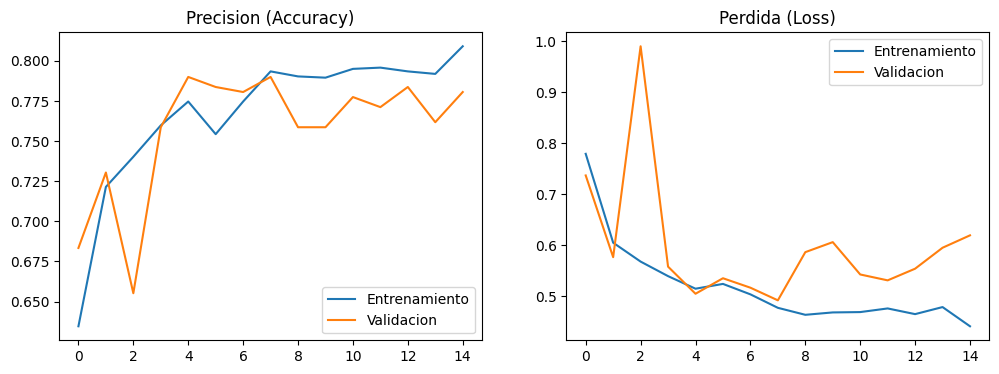

In [24]:
import os
import sys
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# ========================================================
# 1. Configuracion del Entorno (Colab vs Local)
# ========================================================
if 'google.colab' in sys.modules:
    print("Entorno: Google Colab detectado. Montando Drive...")
    from google.colab import drive
    drive.mount('/content/drive')
    base_dir = '/content/drive/MyDrive/dataset_doom_animalCrossing'
else:
    print("Entorno: Local detectado.")
    base_dir = './dataset_videojuegos'

# ========================================================
# 2. Carga y Preparacion del Dataset
# ========================================================
BATCH_SIZE = 32
IMG_SIZE = (150, 150)

print("\nCargando datos de entrenamiento y validacion...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
print(f"Clases detectadas: {class_names}")

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# ========================================================
# 3. Creacion del Modelo (CNN)
# ========================================================
# Data Augmentation mas intenso para evitar memorizacion
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
  layers.RandomContrast(0.2),
  layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
])

model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Un Dropout extra antes de aplanar para "limpiar" caracteristicas
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.Dense(1, activation='sigmoid')
])

# Tasa de aprendizaje (Learning Rate) mas baja para un ajuste mas fino
optimizer_fino = tf.keras.optimizers.Adam(learning_rate=0.0005)

model.compile(optimizer=optimizer_fino,
              loss='binary_crossentropy',
              metrics=['accuracy'])

# ========================================================
# 4. Entrenamiento
# ========================================================
# EarlyStopping activado para detenerse en el mejor momento
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

epochs = 150
print("\nIniciando entrenamiento...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    callbacks=[early_stop]
)

# ========================================================
# 5. Guardar el Modelo
# ========================================================
model_path = 'modelo_doom_vs_ac.keras'
model.save(model_path)
print(f"\n¡Modelo guardado exitosamente como '{model_path}'!")

if 'google.colab' in sys.modules:
    drive_path = '/content/drive/MyDrive/modelo_doom_vs_ac.keras'
    model.save(drive_path)
    print(f"Copia de seguridad guardada en Drive: '{drive_path}'")

# ========================================================
# 6. Graficas de Resultados
# ========================================================
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Entrenamiento')
plt.plot(val_acc, label='Validacion')
plt.title('Precision (Accuracy)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Entrenamiento')
plt.plot(val_loss, label='Validacion')
plt.title('Perdida (Loss)')
plt.legend()
plt.show()